# Verification Results Analysis

### Semantics clarification
- `result == sat`  → **Counterexample exists** (property violated)
- `result == unsat` → **Property proven**
- `sat True / sat False` column:
  - `True`  → verification finished successfully
  - `False` → verification failed / timed out / incomplete


In [34]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

# Paths
results_path = "../results/diff_pix/results.csv"
stats_path = "../results/diff_pix/input_change_stats.csv"
out_path = "../results/diff_pix/combined_results.csv"

# Load CSVs
df_results = pd.read_csv(results_path)
df_stats = pd.read_csv(stats_path)

# Create instance_id from row number
df_stats.insert(0, "instance_id", range(1,1+len(df_stats)))

df_merged = pd.merge(
    df_stats,
    df_results,
    on="instance_id",
    how="left"
)

# Sort and reset index (optional but safe)
df_merged = df_merged.sort_values("instance_id").reset_index(drop=True)

# Save combined CSV
df_merged.to_csv(out_path, index=False)

print(f"Saved: {out_path}")

Saved: ../results/diff_pix/combined_results.csv


In [35]:
CSV_PATH = out_path  
TOTAL_PIXELS_DEFAULT = 150528       # <-- set to your image size (e.g., 224*224*3 = 150528)
SAVE_FIGS = True
FIG_DIR = "figs"

In [36]:
df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(252, 23)


,instance_id,image,tag,is_global,segment_index,eps,k,score,bbox,num_changed,...,pattern,onnx,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable
0,1,n01558993_robin,n01558993_robin_global,True,-1,0.0001,15,NaN,NaN,45,...,global,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k15_eps_0.0001.v...,1200.0,timeout False,-2.712000e+11,30.0,1280.064666,1286.970044,0.0
1,2,n01558993_robin,n01558993_robin_global,True,-1,0.0001,30,NaN,NaN,90,...,global,onnx/vgg16-7.onnx,vnnlib/n01558993_robin_global_k30_eps_0.0001.v...,1200.0,timeout False,-1.922129e+11,15.0,1441.609780,1451.232700,0.0
2,3,n01558993_robin,n01558993_robin_global,True,-1,0.0001,45,NaN,NaN,135,...,global,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,n01558993_robin,n01558993_robin_global,True,-1,0.0001,60,NaN,NaN,180,...,global,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,n01558993_robin,n01558993_robin_global,True,-1,0.0001,75,NaN,NaN,225,...,global,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
def parse_eps_from_vnnlib(vnnlib: str):
    if not isinstance(vnnlib, str):
        return np.nan
    m = re.search(r"eps[_=]([0-9]*\.?[0-9]+)", vnnlib)
    return float(m.group(1)) if m else np.nan

def parse_seg_from_vnnlib(vnnlib: str):
    if not isinstance(vnnlib, str):
        return np.nan
    m = re.search(r"_seg(\d+)_", vnnlib)
    return int(m.group(1)) if m else np.nan

def normalize_result(s: str):
    """Map raw result strings into consistent labels.

    Returns:
      attack_label in {SAT, UNSAT, None}
      bnb_label in {safe, timeout, other, None}
    """
    if not isinstance(s, str):
        return (None, None)

    ss = s.strip().lower()

    # Attack interpretation
    attack = None
    if "sat" in ss:
        attack = "SAT"
    if "unsat" in ss:
        # make UNSAT override plain 'sat' substring cases (rare)
        attack = "UNSAT"

    # BnB interpretation
    bnb = None
    if "timeout" in ss:
        bnb = "timeout"
    elif "safe" in ss or "verified" in ss or "unsat true" in ss:
        # depending on your pipeline, safe might be explicit or implied
        bnb = "safe"
    elif "sat" in ss:
        # sat means counterexample found; not safe
        bnb = "counterexample"
    else:
        bnb = "other"

    return (attack, bnb)

# Fill eps/segment if missing
if "eps" not in df.columns or df["eps"].isna().all():
    df["eps"] = df["vnnlib"].apply(parse_eps_from_vnnlib)

if "segment_index" not in df.columns or df["segment_index"].isna().all():
    df["segment_index"] = df["vnnlib"].apply(parse_seg_from_vnnlib)

# Percentage change
df["pct_change"] = (df["num_changed"] / TOTAL_PIXELS_DEFAULT) * 100.0

# Parse outcomes
parsed = df["result"].apply(normalize_result)
df["attack_outcome"] = parsed.apply(lambda x: x[0])
df["bnb_outcome"] = parsed.apply(lambda x: x[1])

# Keep rows with a defined k/num_changed and eps
df_clean = df.copy()
df_clean = df_clean[~df_clean["num_changed"].isna()]
df_clean = df_clean[~df_clean["eps"].isna()]

print("clean:", df_clean.shape)
df_clean[["eps","k","num_changed","pct_change","result","attack_outcome","bnb_outcome","bab_time","all_time","domains_visited"]].head(10)


clean: (252, 26)


,eps,k,num_changed,pct_change,result,attack_outcome,bnb_outcome,bab_time,all_time,domains_visited
0,0.0001,15,45,0.029895,timeout False,None,timeout,1280.064666,1286.970044,30.0
1,0.0001,30,90,0.059790,timeout False,None,timeout,1441.609780,1451.232700,15.0
2,0.0001,45,135,0.089684,NaN,None,None,NaN,NaN,NaN
3,0.0001,60,180,0.119579,NaN,None,None,NaN,NaN,NaN
4,0.0001,75,225,0.149474,NaN,None,None,NaN,NaN,NaN
5,0.0001,90,270,0.179369,NaN,None,None,NaN,NaN,NaN
6,0.0001,105,315,0.209263,NaN,None,None,NaN,NaN,NaN
7,0.0001,120,360,0.239158,NaN,None,None,NaN,NaN,NaN
8,0.0001,135,405,0.269053,NaN,None,None,NaN,NaN,NaN
9,0.0001,151,453,0.300941,NaN,None,None,NaN,NaN,NaN


In [38]:
# Bin percentage change for aggregated plots
BIN_WIDTH = 0.05  # percentage points; adjust (e.g., 0.1)
df_clean["pct_bin"] = (df_clean["pct_change"] / BIN_WIDTH).round().astype(int) * BIN_WIDTH

df_clean["eps_str"] = df_clean["eps"].map(lambda x: f"{x:g}")
sorted_eps = sorted(df_clean["eps"].dropna().unique())

sorted_eps

[np.float64(0.0001),
 np.float64(0.0003),
 np.float64(0.0005),
 np.float64(0.0007),
 np.float64(0.001),
 np.float64(0.005),
 np.float64(0.01)]

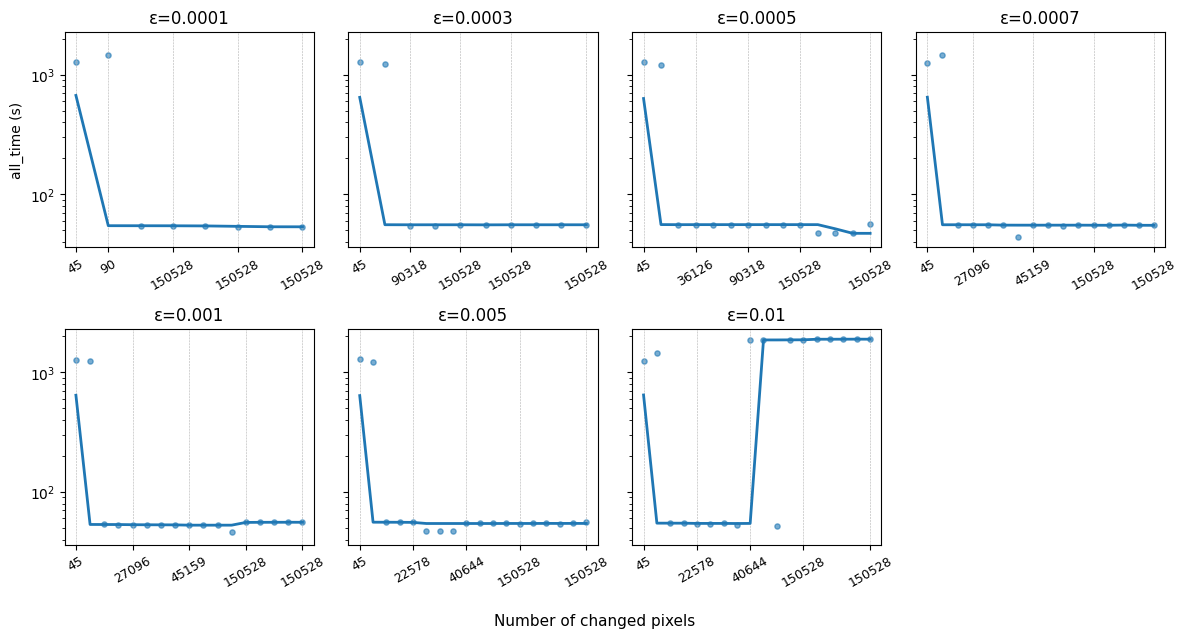

In [39]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_fig_dir():
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)

ensure_fig_dir()

TIME_COL = "all_time" if "all_time" in df_clean.columns else "bab_time"

ROLLING_WINDOW = 7
SMOOTH_METHOD = "median"
MIN_POINTS = 3

# Clean data (NOTE: use num_changed, not pct_change)
d = df_clean.dropna(subset=[TIME_COL, "num_changed", "eps"]).copy()
d["eps_str"] = d["eps"].map(lambda x: f"{x:g}")

eps_list = sorted(d["eps"].unique())
n_eps = len(eps_list)

# ---- 2-row layout ----
N_ROWS = 2
N_COLS = math.ceil(n_eps / N_ROWS)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(3 * N_COLS, 3.2 * N_ROWS),
    sharey=True
)

axes = axes.flatten()

for ax, eps in zip(axes, eps_list):
    epss = f"{eps:g}"
    sub = d[d["eps_str"] == epss].sort_values("num_changed")

    if len(sub) < MIN_POINTS:
        ax.set_title(f"ε={epss}\n(no data)")
        ax.axis("off")
        continue

    # ---- ORDINAL X (even spacing) ----
    x_pos = np.arange(len(sub))               # evenly spaced
    x_labels = sub["num_changed"].astype(int).astype(str).to_list()

    y = sub[TIME_COL].to_numpy()

    # smoothing over ordinal axis
    y_series = pd.Series(y)
    if SMOOTH_METHOD == "mean":
        y_smooth = y_series.rolling(
            ROLLING_WINDOW, center=True, min_periods=1
        ).mean()
    else:
        y_smooth = y_series.rolling(
            ROLLING_WINDOW, center=True, min_periods=1
        ).median()

    # raw points
    ax.scatter(x_pos, y, s=14, alpha=0.6)

    # smooth trend
    ax.plot(x_pos, y_smooth, linewidth=2)

    ax.set_title(f"ε={epss}", fontsize=12)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4)

    # fewer x ticks for readability
    tick_idx = np.linspace(0, len(x_pos) - 1, min(5, len(x_pos))).astype(int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=30, fontsize=9)

# turn off unused subplots
for ax in axes[len(eps_list):]:
    ax.axis("off")

axes[0].set_ylabel(f"{TIME_COL} (s)")
fig.supxlabel("Number of changed pixels", fontsize=11)

plt.yscale("log")
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(
        f"{FIG_DIR}/time_vs_num_changed_small_multiples_eps_2rows.pdf",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

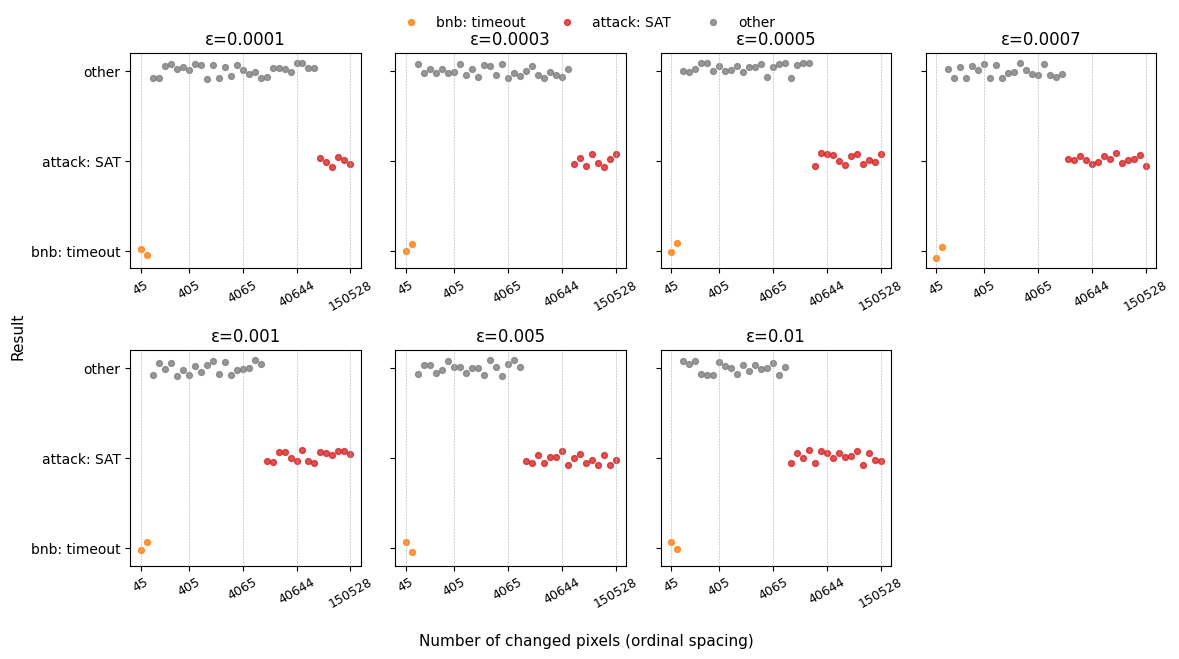

In [40]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_fig_dir():
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)

ensure_fig_dir()

# Build unified result label (same logic as before)
def result_band(row):
    if row.get("bnb_outcome", None) == "timeout":
        return "bnb: timeout"
    if row.get("bnb_outcome", None) == "safe":
        return "bnb: safe"
    if row.get("attack_outcome", None) == "SAT":
        return "attack: SAT"
    if row.get("attack_outcome", None) == "UNSAT":
        return "attack: UNSAT"
    return "other"

df_clean = df_clean.copy()
df_clean["result_band"] = df_clean.apply(result_band, axis=1)

# Keep valid rows
d = df_clean.dropna(subset=["num_changed", "eps", "result_band"]).copy()
d["eps_str"] = d["eps"].map(lambda x: f"{x:g}")

# ---- ONLY keep categories that actually appear ----
present_order = [
    "bnb: safe",
    "bnb: timeout",
    "attack: SAT",
    "attack: UNSAT",
    "other",
]
present = [c for c in present_order if (d["result_band"] == c).any()]

Y_MAP = {r: i for i, r in enumerate(present)}

# If you want to completely hide "other" even if present:
# present = [c for c in present if c != "other"]

# Colors (only used for present categories)
COLOR_MAP = {
    "bnb: safe":    "#2ca02c",
    "bnb: timeout": "#ff7f0e",
    "attack: SAT":  "#d62728",
    "attack: UNSAT":"#1f77b4",
    "other":        "#7f7f7f",
}

d["y_val"] = d["result_band"].map(Y_MAP)

eps_list = sorted(d["eps"].unique())
N_ROWS = 2
N_COLS = math.ceil(len(eps_list) / N_ROWS)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(3 * N_COLS, 3.2 * N_ROWS),
    sharey=True
)
axes = axes.flatten()

rng = np.random.default_rng(0)

for ax, eps in zip(axes, eps_list):
    epss = f"{eps:g}"
    sub = d[d["eps_str"] == epss].sort_values("num_changed")

    if sub.empty:
        ax.set_title(f"ε={epss}\n(no data)")
        ax.axis("off")
        continue

    # ordinal x positions (equal spacing)
    x_pos = np.arange(len(sub))
    x_labels = sub["num_changed"].astype(int).astype(str).to_list()

    y = sub["y_val"].to_numpy()
    y_jitter = y + (rng.random(len(y)) - 0.5) * 0.18

    # plot only categories that exist (present)
    for cat in present:
        mask = (sub["result_band"] == cat).to_numpy()
        if not mask.any():
            continue
        ax.scatter(
            x_pos[mask], y_jitter[mask],
            s=18, alpha=0.8,
            color=COLOR_MAP.get(cat, "#7f7f7f"),
            label=cat
        )

    ax.set_title(f"ε={epss}", fontsize=12)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4)

    # readable x ticks
    tick_idx = np.linspace(0, len(x_pos) - 1, min(5, len(x_pos))).astype(int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=30, fontsize=9)

# turn off unused subplots
for ax in axes[len(eps_list):]:
    ax.axis("off")

# y-axis labels only for categories that exist
axes[0].set_yticks(range(len(present)))
axes[0].set_yticklabels(present, fontsize=10)

fig.supxlabel("Number of changed pixels (ordinal spacing)", fontsize=11)
fig.supylabel("Result", fontsize=11)

# legend ONLY for present categories (single legend)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(3, len(present)),
           frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(f"{FIG_DIR}/result_vs_num_changed_present_only.pdf",
                dpi=300, bbox_inches="tight")

plt.show()